In [1]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
from astropy.cosmology import Planck18
import matplotlib.pyplot as plt

def g_kcorr(gr,z):
    '''
    This function returns the k correction for SDSSgr band 
    
    According to the Chilingarian et al. 2010 from which this k-correction is based, 
    we can only apply this on z<0.5    
    '''
    
    # it is power of z * power of gr
    coeff_10 = -0.900332 * (z**1) * (gr**0)
    coeff_11 = 3.97338  * (z**1) * (gr**1)
    coeff_12 = 0.774394  * (z**1) * (gr**2)
    coeff_13 = -1.09389  * (z**1) * (gr**3)
    
    coeff_20 = 3.65877  * (z**2) * (gr**0)
    coeff_21 = -8.04213 * (z**2) * (gr**1)
    coeff_22 = 11.0321 * (z**2) * (gr**2)
    coeff_23 = 0.781176 * (z**2) * (gr**3)
    
    coeff_30 = -16.7457 * (z**3) * (gr**0)
    coeff_31 = -31.1241 * (z**3) * (gr**1)
    coeff_32 = -17.5553 * (z**3) * (gr**2)
    
    coeff_40 = 87.3565 * (z**4) * (gr**0)
    coeff_41 = 71.5801 * (z**4) * (gr**1)
    
    coeff_50 = -123.671 * (z**5) * (gr**0)

    kg =  (coeff_10 + coeff_11 + coeff_12 + coeff_13) + (coeff_20 + coeff_21 + coeff_22 + coeff_23) + (coeff_30 + coeff_31 + coeff_32) + (coeff_40 + coeff_41) + (coeff_50)
    
    return kg

def get_stellar_mass_mia( gr_col, gmag, zred, d_in_mpc=None, input_zred=True):
    '''
    we use the 2 color prescriptions here. One from SAGA and the updated one from Mia's paper.
    Note that Mia's formula is only valid for Mstar < 1e10 though which is okay for us!
    '''
    #use redshift to convert to absolute magnitude
    from astropy.cosmology import Planck18

    if input_zred:
        #convert the zred to the luminosity distance 
        d = Planck18.luminosity_distance(zred)
        d_in_pc = d.value * 1e6
        #M = m + 5 - 5*log10(d/pc) - Kcor
        kg = g_kcorr(gr_col,zred)
    else:
        #the input is in distance!
        d_in_pc = d_in_mpc * 1e6
        kg = g_kcorr(gr_col,zred)

    Mg = gmag + 5 - 5*np.log10(d_in_pc) - kg
    
    log_mstar = (1.433 * gr_col) + 0.00153 * (Mg**2) - (0.335 * Mg) + 2.072
    
    return log_mstar


In [191]:
gkv_cat_hdus = fits.open("data/GAMA/gkvScienceCatv02.fits")

In [192]:
gkv_cat = Table(gkv_cat_hdus[1].data)


In [193]:
len(gkv_cat)

2232985

In [194]:
gkv_cat_f = gkv_cat[(gkv_cat["SC"] >= 7) & (gkv_cat["NQ"] > 2)]

In [195]:
gkv_cat_f = gkv_cat_f["RAcen","Deccen","Z","mag", "flux_gt", "flux_gl", "flux_rt", "flux_rl"]

In [196]:
len(gkv_cat_f)

195432

In [153]:
gkv_cat_f["mag_r"] = 8.9 - 2.5*np.log10(gkv_cat_f["flux_rt"])
gkv_cat_f["mag_g"] = 8.9 - 2.5*np.log10(gkv_cat_f["flux_gt"])

## we could estimate stellar mass using the mia relation, and then select only the 9.25 objects
gkv_cat_f["gr_col"] = gkv_cat_f["mag_g"].data - gkv_cat_f["mag_r"].data

/var/folders/xc/7gkvk2nx1c13pnylpzhtjww80000gp/T/ipykernel_67137/2828222985.py:2: RuntimeWarning: invalid value encountered in log10
  gkv_cat_f["mag_g"] = 8.9 - 2.5*np.log10(gkv_cat_f["flux_gt"])


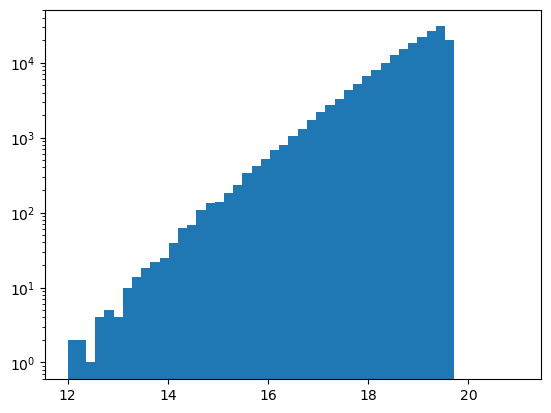

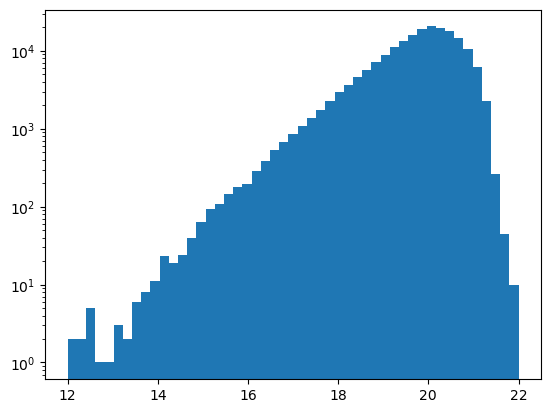

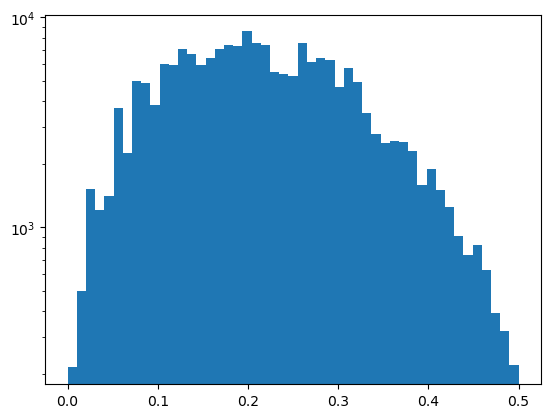

In [156]:
plt.hist(gkv_cat_f["mag_r"],bins=np.linspace(12,21,50))
plt.yscale("log")
plt.show()

plt.hist(gkv_cat_f["mag_g"],bins=np.linspace(12,22,50))
plt.yscale("log")
plt.show()



plt.hist(gkv_cat_f["Z"],bins=np.linspace(0,0.5,50))
plt.yscale("log")
plt.show()

In [158]:
gkv_cat_f = gkv_cat_f[gkv_cat_f["Z"] < 0.2]

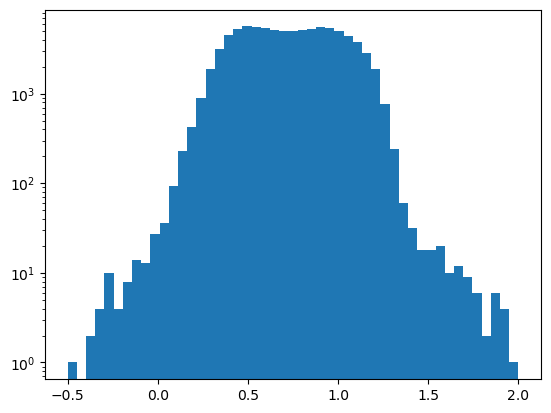

In [159]:

plt.hist(gkv_cat_f["gr_col"],bins=np.linspace(-0.5,2,50))
plt.yscale("log")
plt.show()


In [162]:
print(np.sum(gkv_cat_f["mag_r"] < 25))
print(np.sum(gkv_cat_f["mag_g"] < 25))

88903
88852


In [164]:
gkv_cat_f["MSTAR"] = get_stellar_mass_mia(gkv_cat_f["gr_col"], gkv_cat_f["mag_g"], gkv_cat_f["Z"])

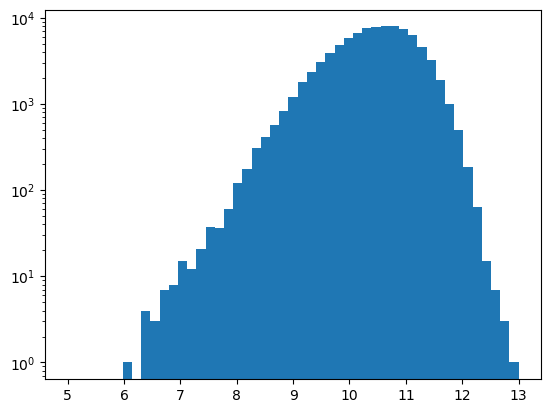

In [165]:

plt.hist(gkv_cat_f["MSTAR"],bins=np.linspace(5,13,50))
plt.yscale("log")
plt.show()


In [169]:
gkv_dwarfs = gkv_cat_f[(gkv_cat_f["MSTAR"]<9.25) & (gkv_cat_f["MSTAR"]> 6)]

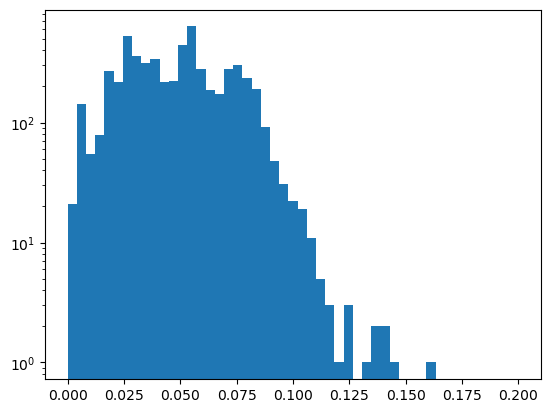

In [172]:
plt.hist(gkv_dwarfs["Z"],bins=np.linspace(0,0.2,50))
plt.yscale("log")
plt.show()

In [173]:
## save the catalog of ra,dec,z and mstar from GAMA

In [182]:
print("6 < Mstar < 7 Counts =", np.sum((gkv_dwarfs["MSTAR"] < 7) & (gkv_dwarfs["MSTAR"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((gkv_dwarfs["MSTAR"] < 8) & (gkv_dwarfs["MSTAR"] > 7)))
print("8 < Mstar < 9.25 Counts =", np.sum((gkv_dwarfs["MSTAR"] < 9.25) & (gkv_dwarfs["MSTAR"] > 8)))

6 < Mstar < 7 Counts = 24
7 < Mstar < 8 Counts = 224
8 < Mstar < 9.25 Counts = 5461


In [183]:
len(gkv_dwarfs["MSTAR"])

5709

In [189]:
gkv_dwarfs.write("data/GAMA/gama_dwarf_cat.fits",overwrite=True)

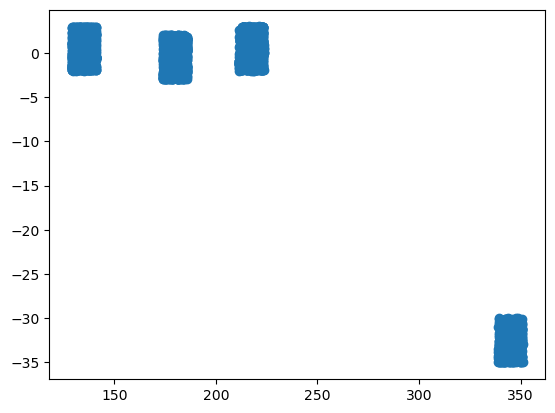

In [186]:
plt.scatter(gkv_dwarfs["RAcen"].data, gkv_dwarfs["Deccen"].data)
plt.show()